# Notebook 1: Setup & Exploratory Data Analysis

Welcome to the **Hack for LA Data Science** setup template tutorial!

This is the first of three notebooks that walk you through a complete NLP (Natural Language Processing) text classification pipeline. By the end of this series, you'll have trained a model that can read a news headline and predict its category.

**What you'll do in this notebook:**

1. Set up your Python environment and install dependencies
2. Load a real-world news dataset from Hugging Face
3. Explore the data to understand what we're working with

**Why this matters:** Before building any model, you need to understand your data. Exploratory Data Analysis (EDA) helps you catch problems early — things like imbalanced classes, unexpected text lengths, or missing values — that would otherwise silently hurt your model's performance.

---

### Notebook series

| Notebook | Focus |
|---|---|
| **01 — Setup & EDA** (you are here) | Environment, data loading, exploration |
| 02 — Train & Evaluate | Build, train, and evaluate a text classifier |
| 03 — Serve & Predict | Load the trained model and make predictions |

---
## 1. Environment Setup

Before writing any code, we need to make sure our tools are installed and configured. Think of this like setting up your workbench before starting a project.

### What is a virtual environment?

A **virtual environment** is an isolated Python installation. Most operating systems come with a version of Python already installed: if you open a terminal or a powershell and type `python` you'll see something like the following:

<div>
<img src="./shell1.png" width="500"/>
</div>

Image borrowed from [tutorialsteacher](https://www.tutorialsteacher.com/python/python-interective-shell)

Because there's a lot of variability in dependencies and versions, it's standard practice to use a virtual environment to keep your project's packages separate from your system Python, so you won't accidentally break other projects (or vice versa). Every serious Python project should use one.

### Prerequisites
- **Python 3.11+** installed on your system
- This notebook should be run from the `notebooks/` directory inside the project

### 1a. Locate the Project Root

Now we need to determine the root of the project we're setting everything up in. This matters because we need to find files like `requirements.txt` and `configs/baseline.yaml` regardless of where you opened the notebook from.

In [51]:
import subprocess, sys, os
from pathlib import Path

# Try to detect the project root automatically.
# If running in VS Code, __vsc_ipynb_file__ gives us the notebook's path.
# Otherwise, we assume the notebook is in a 'notebooks/' subdirectory.
PROJECT_ROOT = (
    Path("__vsc_ipynb_file__").resolve().parent.parent
    if "__vsc_ipynb_file__" in dir()
    else Path.cwd().parent
)

# Safety check: if we can't find requirements.txt, we're probably already at the root
if not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/Bartley/Documents/personal_dev/h4la/repos/data-science/tutorials/setup_template


### 1b. Create the Virtual Environment

This creates a virtual environment called `nlp311` in the project root. If it already exists, the cell simply skips creation.

> **Note:** Creating the venv from inside the notebook is convenient for this tutorial, but in day-to-day work you'd typically do this once from the terminal.

In [52]:
venv_path = PROJECT_ROOT / "nlp311"

if not venv_path.exists():
    # this is calling python -m venv venv_path
    subprocess.check_call([sys.executable, "-m", "venv", str(venv_path)])
    print(f"Created virtual environment at {venv_path}")
else:
    print(f"Virtual environment already exists at {venv_path}")

# Show the activation command for terminal use
if sys.platform == "win32":
    activate_cmd = str(venv_path / "Scripts" / "activate")
else:
    activate_cmd = f"source {venv_path / 'bin' / 'activate'}"

print(f"\nTo activate in a terminal, run:\n  {activate_cmd}")

Virtual environment already exists at /Users/Bartley/Documents/personal_dev/h4la/repos/data-science/tutorials/setup_template/nlp311

To activate in a terminal, run:
  source /Users/Bartley/Documents/personal_dev/h4la/repos/data-science/tutorials/setup_template/nlp311/bin/activate


### 1c. Install Dependencies

The `requirements.txt` file lists every Python package this project needs, along with specific version numbers. Pinning versions ensures everyone on the team gets the same behavior — no "works on my machine" surprises.

Key packages we're installing:
- **pandas** — tabular data manipulation (think Excel spreadsheets in Python)
- **scikit-learn** — classic machine learning algorithms and utilities
- **datasets** — Hugging Face's library for downloading and managing datasets
- **mlflow** — experiment tracking (logs your model runs so you can compare them later)
- **matplotlib** — plotting and visualization
- **fastapi / uvicorn** — for serving predictions as a web API (used in notebook 3)

In [53]:
!pip install -r ../requirements.txt

### 1d. Configure Environment Variables (`.env`)

One of the worst things you can do as a developer is hardcode filepaths and important keys that are unique to your environment. This makes it harder to reproduce and run your code in other environments & other machines. Environment variables let you configure things like file paths without hardcoding them in your source code. We store ours in a `.env` file, which is loaded automatically by the `python-dotenv` package.

This project is going to use two variables:
- `MLFLOW_TRACKING_URI` — where MLflow stores experiment data (default: `./mlruns`)
- `DATA_CACHE_DIR` — where downloaded datasets are cached (default: `./.hf_cache`)

The cell below copies the example file to `.env` if you haven't already. Projects like this one will often give you an example `.env` file so you know which variables you need to set to be able to run it.

In [54]:
import shutil

env_example = PROJECT_ROOT / ".env.example"
env_file = PROJECT_ROOT / ".env"

if not env_file.exists():
    shutil.copy(env_example, env_file)
    print(f"Copied {env_example.name} -> {env_file.name}")
else:
    print(f".env already exists — skipping copy")

print(f"\nContents of .env:")
print(env_file.read_text())

.env already exists — skipping copy

Contents of .env:
MLFLOW_TRACKING_URL=./mlruns
DATA_CACHE_DIR=./.hf_cache




### 1e. Verify Installation

Let's do a quick sanity check: import the key packages and print their versions. If any of these fail, go back and re-run the `pip install` cell above.

In [55]:
import pandas as pd
import sklearn
import mlflow
import datasets
import fastapi
import matplotlib

for pkg in [pd, sklearn, mlflow, datasets, fastapi, matplotlib]:
    print(f"{pkg.__name__:20s} {pkg.__version__}")

print("\nAll packages imported successfully!")

pandas               2.2.2
sklearn              1.5.2
mlflow               2.16.2
datasets             3.0.1
fastapi              0.115.0
matplotlib           3.9.2

All packages imported successfully!


---
## 2. Imports & Configuration

Now that our environment is ready, let's import the libraries we'll use and load the project configuration.

### Why a config file?

Instead of scattering settings throughout the code (dataset name, model parameters, etc.), we keep them all in one YAML file: `configs/baseline.yaml`. This makes it easy to:
- **Change experiments** without editing code (just tweak the YAML)
- **Reproduce results** by saving/sharing the config alongside your model
- **Compare runs** by seeing exactly which settings produced which results

In [56]:
import os, sys, yaml
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# Make sure Python can find our src/ modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import set_all_seeds, get_env

### Set the random seed

Machine learning involves randomness (shuffling data, initializing weights, etc.). Setting a **seed** means the random number generator always produces the same sequence, so your results are **reproducible** — you (or a teammate) can re-run this notebook and get the exact same numbers.

In [57]:
set_all_seeds(42)
print("Random seed set to 42 — results will be reproducible.")

Random seed set to 42 — results will be reproducible.


### Load the configuration file

Let's load `configs/baseline.yaml` and see what's inside. Don't worry about understanding every parameter right now — we'll explain each one when we use it.

In [58]:
cfg_path = PROJECT_ROOT / "configs" / "baseline.yaml"

with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

print("Configuration:")
for key, value in cfg.items():
    print(f"  {key}: {value}")

Configuration:
  experiment_name: t0_setup_template
  dataset: ag_news
  test_size: 0.2
  random_state: 42
  tfidf: {'max_features': 30000, 'ngram_range': [1, 2]}
  model: {'type': 'logreg', 'C': 2.0, 'max_iter': 200}
  metrics: {'average': 'macro'}


**What these settings mean:**

| Setting | Value | What it controls |
|---|---|---|
| `dataset` | `ag_news` | Which Hugging Face dataset to download |
| `test_size` | `0.2` | 20% of training data is held out for validation |
| `random_state` | `42` | Seed for the train/validation split |
| `tfidf.max_features` | `30000` | Keep only the 30k most common words |
| `tfidf.ngram_range` | `[1, 2]` | Use single words *and* two-word phrases |
| `model.C` | `2.0` | Regularization strength (higher = less regularization) |
| `model.max_iter` | `200` | Max training iterations for the classifier |
| `metrics.average` | `macro` | Average F1 equally across all classes |

We'll revisit these in notebook 2 when we actually build the model.

---
## 3. Load the Dataset

### What is AG News?

[AG News](https://huggingface.co/datasets/fancyzhx/ag_news) is a widely-used benchmark dataset for text classification. It contains over a million articles in the original dataset, but we will use a sampled set that contains **120,000 training** and **7,600 test** news articles, each labeled with one of four categories:

| Label | Category |
|---|---|
| 0 | World |
| 1 | Sports |
| 2 | Business |
| 3 | Sci/Tech |

We're using Hugging Face's `datasets` library to download it. The library automatically caches the download so you only need to wait once.

### What are train / validation / test splits?

In machine learning, we split data into separate groups:
- **Train** — the model learns from this data
- **Validation** — used to tune settings and check progress *during* development
- **Test** — held back until the very end to get an honest measure of performance

This prevents the model from "cheating" by memorizing answers it'll be tested on.

In [59]:
# Where to cache the downloaded dataset (from our .env file)
cache_dir = get_env("DATA_CACHE_DIR", "./.hf_cache")
cache_dir = str(PROJECT_ROOT / cache_dir)

# Download the dataset (or load from cache if already downloaded)
ds = load_dataset(cfg["dataset"], cache_dir=cache_dir)
print(f"Dataset splits available: {list(ds.keys())}")

Dataset splits available: ['train', 'test']


### Convert to pandas DataFrames

Hugging Face datasets have their own format, but pandas DataFrames are more familiar and flexible for exploration. Let's convert.

In [60]:
train_df = pd.DataFrame(ds["train"])
test_df  = pd.DataFrame(ds["test"])

# Some datasets include a validation split; AG News does not,
# so we'll create one ourselves in notebook 2.
valid_df = pd.DataFrame(ds["validation"]) if "validation" in ds else None

print(f"Train: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
if valid_df is not None:
    print(f"Valid: {valid_df.shape[0]:,} rows")
else:
    print("Valid: None (we'll create this split in notebook 2)")
print(f"Test:  {test_df.shape[0]:,} rows")

Train: 120,000 rows, 2 columns
Valid: None (we'll create this split in notebook 2)
Test:  7,600 rows


### Peek at the data

Always look at a few rows before doing anything else. This helps you spot issues like missing values, weird formatting, or columns you didn't expect.

In [61]:
train_df.head(10)

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


Each row has:
- `text` — the news article content
- `label` — an integer (0–3) representing the category

Notice the labels are numbers, not names. That's typical — it's more efficient for the model. We'll map them to human-readable names when we need to.

---
## 4. Exploratory Data Analysis (EDA)

EDA is a **critical** first step in doing machine learning and data science. 

EDA is about asking questions: *How big is the data? Are the classes balanced? How long are the texts?* These answers shape decisions you'll make later.

### 4a. Basic Statistics

Let's compute some summary stats. We'll count rows, measure text lengths (in tokens — roughly, words), and look at the distribution of labels.

In [62]:
def describe_dataset(df, text_col="text", label_col="label"):
    """
    Compute basic stats for a text classification DataFrame.
    
    'Tokens' here means words (split on whitespace). This is a rough
    approximation — real tokenizers are more sophisticated, but this
    gives us a good-enough picture for EDA.
    """
    # Count words in each text by splitting on spaces
    lengths = df[text_col].astype(str).str.split().map(len)
    # Count how many examples belong to each label
    counts = Counter(df[label_col])
    
    return {
        "rows": len(df),
        "avg_tokens": round(float(lengths.mean()), 1),
        "median_tokens": float(lengths.median()),
        "label_counts": dict(sorted(counts.items())),
    }


print("=== TRAIN ===")
train_stats = describe_dataset(train_df)
for k, v in train_stats.items():
    print(f"  {k}: {v}")

print("\n=== TEST ===")
test_stats = describe_dataset(test_df)
for k, v in test_stats.items():
    print(f"  {k}: {v}")

=== TRAIN ===
  rows: 120000
  avg_tokens: 37.8
  median_tokens: 37.0
  label_counts: {0: 30000, 1: 30000, 2: 30000, 3: 30000}

=== TEST ===
  rows: 7600
  avg_tokens: 37.7
  median_tokens: 37.0
  label_counts: {0: 1900, 1: 1900, 2: 1900, 3: 1900}


**What to look for:**

- **Label counts** — Are they roughly equal? AG News is well-balanced (each class has ~30k examples). If one class had far fewer examples, we'd need strategies like oversampling or class weights to avoid the model ignoring the minority class.
- **Token lengths** — The average and median give you a sense of typical document size. If there's a huge gap between them, it suggests some very long outliers that might need truncation.

### 4b. Token-Length Histogram

A histogram shows the *distribution* — not just the average, but the full shape. Are most texts about the same length, or is there a wide spread? Are there extreme outliers?

This matters because our TF-IDF model (in notebook 2) treats each text as a "bag of words." Very short texts have fewer words to work with; very long ones might be noisy.

Saved plot to: /Users/Bartley/Documents/personal_dev/h4la/repos/data-science/tutorials/setup_template/reports/eda_token_lengths.png


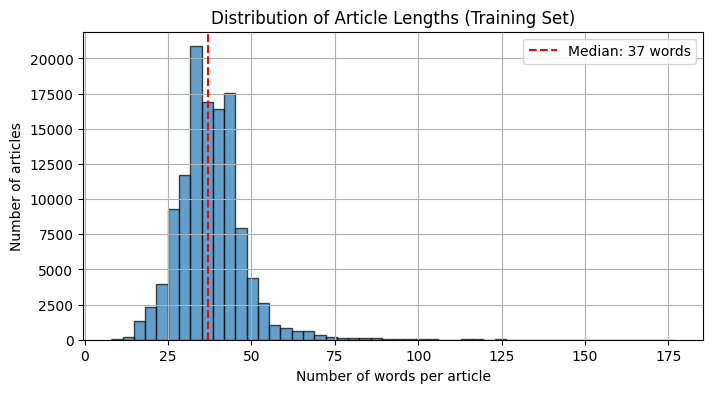

In [63]:
# Count words per training example
lengths = train_df["text"].astype(str).str.split().map(len)

plt.figure(figsize=(8, 4))
lengths.hist(bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Number of words per article")
plt.ylabel("Number of articles")
plt.title("Distribution of Article Lengths (Training Set)")

# Add a vertical line at the median for reference
plt.axvline(lengths.median(), color="red", linestyle="--", label=f"Median: {lengths.median():.0f} words")
plt.legend()

# Save the plot to reports/ so it's available outside the notebook
reports_dir = PROJECT_ROOT / "reports"
reports_dir.mkdir(exist_ok=True)
plt.savefig(reports_dir / "eda_token_lengths.png", dpi=160, bbox_inches="tight")
print(f"Saved plot to: {reports_dir / 'eda_token_lengths.png'}")

plt.show()

### 4c. Label Distribution

Let's visualize how many articles belong to each category. A balanced dataset is easier to model — if one class dominates, the model can get high accuracy just by always predicting that class.

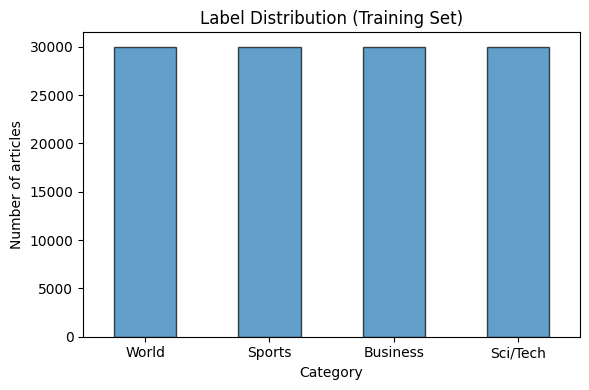


Exact counts:
  World: 30,000
  Sports: 30,000
  Business: 30,000
  Sci/Tech: 30,000


In [64]:
# Map numeric labels to readable names for the plot
label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

label_counts = train_df["label"].value_counts().sort_index()
label_counts.index = [label_names.get(i, i) for i in label_counts.index]

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar", edgecolor="black", alpha=0.7)
plt.xlabel("Category")
plt.ylabel("Number of articles")
plt.title("Label Distribution (Training Set)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nExact counts:")
for name, count in label_counts.items():
    print(f"  {name}: {count:,}")

### 4d. Sample Texts by Category

Numbers and charts are useful, but nothing beats reading actual examples. Let's look at one random article from each category to build intuition about what the model will be working with.

In [65]:
label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

for label_id, name in label_names.items():
    sample = train_df[train_df["label"] == label_id].sample(1, random_state=42).iloc[0]
    print(f"--- {name} (label={label_id}) ---")
    # Show the first 200 characters to keep output manageable
    print(f"{sample['text'][:200]}...\n")

--- World (label=0) ---
Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and woundi...

--- Sports (label=1) ---
Second Andre win in a row boosts US gold medal hopes Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United States of at least two boxing medals Wednesday ...

--- Business (label=2) ---
US house sales fall in July Sales of non-new houses in the US fell last month but still exceeded analyst forecasts....

--- Sci/Tech (label=3) ---
Gartner optimistic about chip numbers But that optimism isn #39;t matched by Infineon, which said that while the market worldwide remains buoyant, the US is a special case and cautioned that growth mi...



---
## 5. Save Shared Objects for Notebook 2

We'll save the DataFrames and config so the next notebook can pick up right where we left off without re-downloading the dataset.

> **Why not just re-run the download?** You could! But saving intermediate results is a good habit — it saves time on large datasets and makes each notebook self-contained.

In [66]:
# Save DataFrames as parquet files (a compact, fast binary format)
data_dir = PROJECT_ROOT / "data" / "interim"
data_dir.mkdir(parents=True, exist_ok=True)

train_df.to_parquet(data_dir / "train.parquet", index=False)
test_df.to_parquet(data_dir / "test.parquet", index=False)
if valid_df is not None:
    valid_df.to_parquet(data_dir / "valid.parquet", index=False)

print(f"Saved DataFrames to {data_dir}/")
print(f"  train.parquet  ({train_df.shape[0]:,} rows)")
print(f"  test.parquet   ({test_df.shape[0]:,} rows)")
if valid_df is not None:
    print(f"  valid.parquet  ({valid_df.shape[0]:,} rows)")

Saved DataFrames to /Users/Bartley/Documents/personal_dev/h4la/repos/data-science/tutorials/setup_template/data/interim/
  train.parquet  (120,000 rows)
  test.parquet   (7,600 rows)


---
## Summary

Here's what we accomplished:

- **Set up** a Python virtual environment and installed all dependencies
- **Loaded** the AG News dataset (120k training articles across 4 categories)
- **Explored** the data: checked text lengths, verified the labels are balanced, and read sample articles
- **Saved** the data for the next notebook

**Key takeaways from our EDA:**
- The dataset is well-balanced (~30k examples per class) — no special handling needed
- Articles are relatively short (typically 30–50 words) — good for a bag-of-words model
- The four categories are distinct enough that even a simple model should do reasonably well

**Next up:** [02_train_and_evaluate.ipynb](./02_train_and_evaluate.ipynb) — we'll build a TF-IDF + Logistic Regression classifier and track the experiment with MLflow.